# Performing pseudobulking on the `InSituExperiment` object

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from insitupy import InSituData, InSituExperiment, CACHE

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [4]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project)
xd.load_all(skip="transcripts")
xd

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       CD20:	(25778, 35416)
       HE:	(25778, 35416, 3)
       HER2:	(25778, 35416)
       nuclei:	(25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_dc_sub_final_colors', 'cell_type_p

### Create `InSituExperiment`

<img src="../../demo_data/demo_screenshots/insituexperiment_generation.jpg" height="250"/>

*Options to generate an InSituExperiment object*

#### Method 1: Manually add `InSituData` objects

In [5]:
exp = InSituExperiment()
exp.add(
    data=xd,
    metadata={
        "slide_id": xd.slide_id,
        "sample_id": xd.sample_id,
        "patient": "A"
    }
    )

In [6]:
exp

InSituExperiment with 1 samples:
           uid  CITAR slide_id    sample_id patient
0     e6e928b2  ++-++  0001879  Replicate 1       A

In the same way also other datasets can be added. For demonstration purposes, we just add the same dataset again and change the metadata.

In [7]:
exp.add(
    data=xd,
    metadata={
        "slide_id": xd.slide_id,
        "sample_id": xd.sample_id,
        "patient": "A",
        "therapy": "drugB"
    }
    )

In [8]:
exp

InSituExperiment with 2 samples:
           uid  CITAR slide_id    sample_id patient therapy
0     e6e928b2  ++-++  0001879  Replicate 1       A     NaN
1     6b2bb1a3  ++-++  0001879  Replicate 1       A   drugB

#### Method 2: From config file

As config file either a csv file or an excel file can be used.

Example of a valid configuration file:

| directory         | experiment_name | date       | patient    |
|-------------------|-----------------|------------|------------|
| /path/to/dataset1 | Experiment 1    | 2023-09-01 | Patient A  |
| /path/to/dataset2 | Experiment 2    | 2023-09-02 | Patient B  |

In [9]:
import pandas as pd
from insitupy import CACHE

# Define the data
data = {
    "directory": [f"{CACHE}\\out\\demo_insitupy_project", f"{CACHE}\\out\\demo_insitupy_project"],
    "patient": ["A", "B"],
    "therapy": ["drugA", "drugB"]
}

# Create a DataFrame
config_df = pd.DataFrame(data)

# Write the DataFrame to a CSV file
config_df.to_csv('../../demo_data/demo_experiment/insituexperiment_config.csv', index=False)

In [10]:
exp = InSituExperiment.from_config(config_path="../../demo_data/demo_experiment/insituexperiment_config.csv")

100%|██████████| 2/2 [00:00<00:00, 465.28it/s]


In [11]:
exp

InSituExperiment with 2 samples:
           uid  CITAR slide_id    sample_id patient therapy
0     fde20e7a  -----  0001879  Replicate 1       A   drugA
1     33c9cccf  -----  0001879  Replicate 1       B   drugB

In [12]:
exp.load_all()

100%|██████████| 2/2 [00:04<00:00,  2.12s/it]


In [13]:
exp

InSituExperiment with 2 samples:
           uid  CITAR slide_id    sample_id patient therapy
0     fde20e7a  +++++  0001879  Replicate 1       A   drugA
1     33c9cccf  +++++  0001879  Replicate 1       B   drugB

#### Method 3: From regions

We can also use regions from an `InSituData` object to split the data into separate datasets and create an `InSituExperiment` from them. This can be used to select the most interesting regions and focus on them for the analysis or to split a TMA dataset into separate datasets for each core.

In [14]:
exp = InSituExperiment.from_regions(
    data=xd, region_key="TMA"
)

A-1
A-2
A-3
B-1
B-2
B-3


In [15]:
exp

InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     37c2b4ff  ++-++  0001879  Replicate 1        TMA         A-1
1     fc1c0d07  ++-++  0001879  Replicate 1        TMA         A-2
2     bc92ded5  ++-++  0001879  Replicate 1        TMA         A-3
3     c8c1ed3a  ++-++  0001879  Replicate 1        TMA         B-1
4     9175dd9a  ++-++  0001879  Replicate 1        TMA         B-2
5     db128074  ++-++  0001879  Replicate 1        TMA         B-3

In [113]:
from insitupy.tools.pseudobulk import get_pseudobulk, plot_psbulk_samples

In [114]:
psbulk=get_pseudobulk(
    exp,
    sample_col='batch',
    groups_col='cell_type_dc_sub_final',
    counts_layer='counts',
    mode='sum',
    min_cells=10,
    min_counts=1000,
    skip_checks=False,
    min_prop=None,
    min_smpls=None,
    remove_empty=True)

In [115]:
psbulk

AnnData object with n_obs × n_vars = 62 × 297
    obs: 'batch', 'cell_type_dc_sub_final', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [119]:
psbulk.layers["psbulk_props"]

array([[0.04761905, 0.80952381, 0.80952381, ..., 0.71428571, 0.85714286,
        0.76190476],
       [0.33333333, 0.61904762, 0.66666667, ..., 0.76190476, 0.42857143,
        0.28571429],
       [0.44444444, 0.83333333, 0.72222222, ..., 0.55555556, 0.61111111,
        0.44444444],
       ...,
       [0.21165644, 0.66257669, 0.66871166, ..., 0.31288344, 0.52760736,
        0.23006135],
       [0.13095238, 0.49603175, 0.60714286, ..., 0.27380952, 0.51984127,
        0.19444444],
       [0.26815642, 0.62569832, 0.78212291, ..., 0.29608939, 0.54748603,
        0.27374302]], shape=(62, 297))

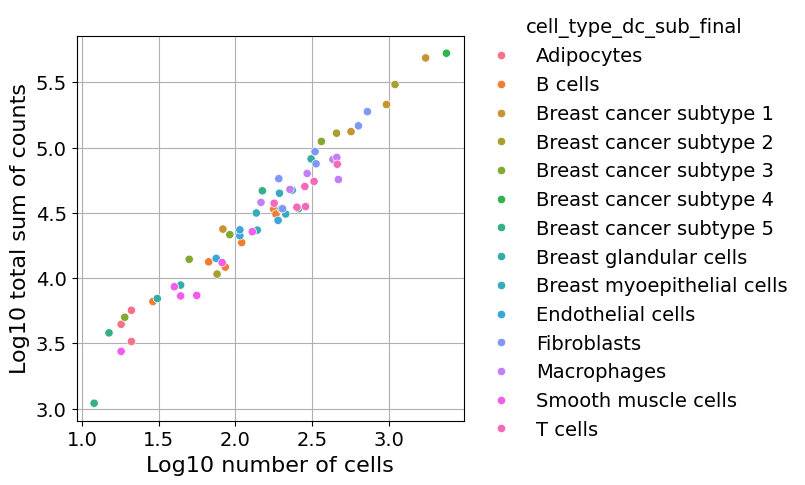

In [117]:
plot_psbulk_samples(psbulk, groupby='cell_type_dc_sub_final')

## Referring to decoupler after this step

Instead of implementing functions in parallel to decoupler, we could just provide the `get_pseudobulk` function for `InSituExperiment` and refer afterwards to decoupler for downstream analysis.

A tutorial on the downstream analysis can be found here: https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html

We should also mention this in the revised paper that InSituPy has direct connections to downstream analysis frameworks like decoupler (for pseudobulking and cell type annotation), scanpy, squidpy, GO term enrichment analysis, ... (what else?)

In [124]:
import decoupler as dc

In [127]:
psbulk.obs

,batch,cell_type_dc_sub_final,psbulk_n_cells,psbulk_counts
9175dd9a-Adipocytes,9175dd9a,Adipocytes,21.0,5661.0
c8c1ed3a-Adipocytes,c8c1ed3a,Adipocytes,21.0,3263.0
db128074-Adipocytes,db128074,Adipocytes,18.0,4423.0
37c2b4ff-B cells,37c2b4ff,B cells,86.0,12128.0
9175dd9a-B cells,9175dd9a,B cells,178.0,33777.0
...,...,...,...,...
9175dd9a-T cells,9175dd9a,T cells,462.0,74505.0
bc92ded5-T cells,bc92ded5,T cells,284.0,50298.0
c8c1ed3a-T cells,c8c1ed3a,T cells,326.0,55025.0
db128074-T cells,db128074,T cells,252.0,34913.0


In [129]:
psbulk

AnnData object with n_obs × n_vars = 62 × 297
    obs: 'batch', 'cell_type_dc_sub_final', 'psbulk_n_cells', 'psbulk_counts'
    uns: 'log1p', 'pca', 'batch_colors', 'cell_type_dc_sub_final_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [128]:
dc.pl.filter_samples(
    adata=psbulk,
    groupby=["cell_type_dc_sub_final", "batch"],
    min_cells=10,
    min_counts=1000,
    figsize=(5, 8),
)

AssertionError: psbulk_* columns not present in adata.obs, this function should be used after running decoupler.pp.pseudobulk

In [131]:
adata = dc.ds.covid5k()
adata

HTTPError: HTTP Error 404: Not Found

In [ ]:
sc.pl.umap(adata, color=["celltype", "disease"], ncols=1)


In [ ]:
pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col="individual",
    groups_col="celltype",
    mode="sum",
)

In [120]:
import scanpy as sc

In [121]:
# Store raw counts in layers
psbulk.layers['counts'] = psbulk.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(psbulk, target_sum=100)
sc.pp.log1p(psbulk)
#sc.pp.scale(pdata, max_value=10)
sc.tl.pca(psbulk)

In [ ]:
#swap_layer(psbulk, 'counts', X_layer_key="counts_log1p", inplace=True) # Return raw counts to X

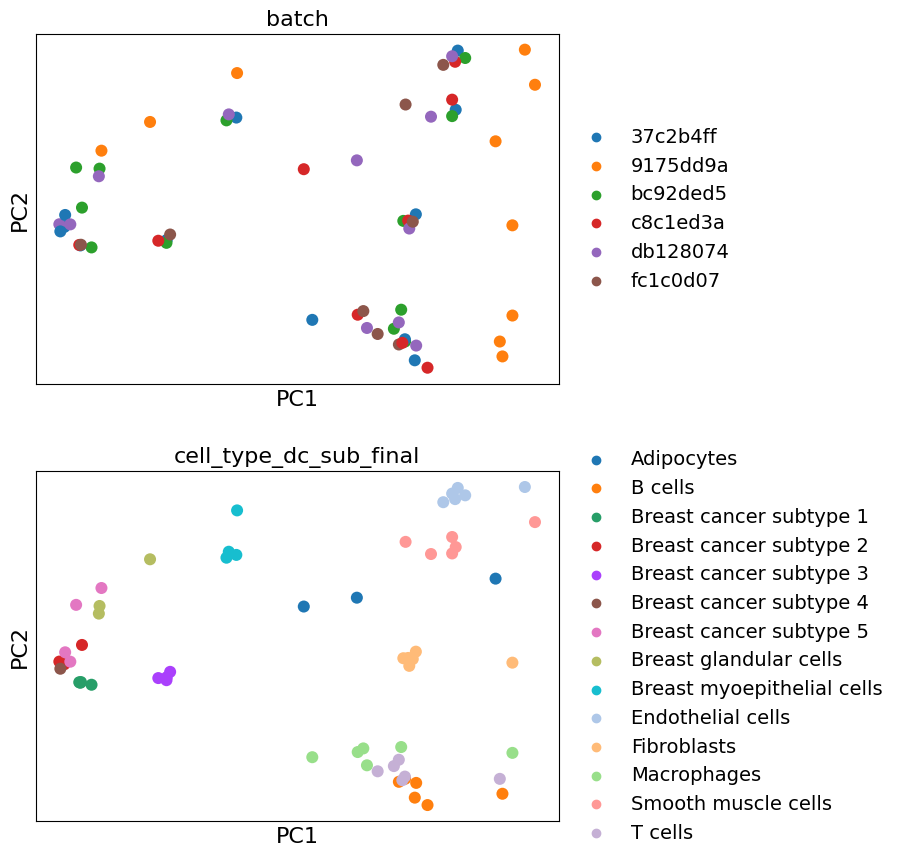

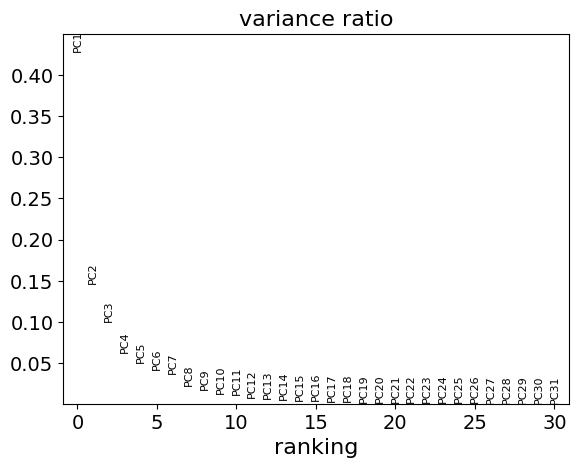

In [123]:
sc.pl.pca(psbulk, color=['batch', 'cell_type_dc_sub_final'], ncols=1, size=300)
sc.pl.pca_variance_ratio(psbulk)

In [118]:
psbulk.obs

,batch,cell_type_dc_sub_final,psbulk_n_cells,psbulk_counts
9175dd9a-Adipocytes,9175dd9a,Adipocytes,21.0,5661.0
c8c1ed3a-Adipocytes,c8c1ed3a,Adipocytes,21.0,3263.0
db128074-Adipocytes,db128074,Adipocytes,18.0,4423.0
37c2b4ff-B cells,37c2b4ff,B cells,86.0,12128.0
9175dd9a-B cells,9175dd9a,B cells,178.0,33777.0
...,...,...,...,...
9175dd9a-T cells,9175dd9a,T cells,462.0,74505.0
bc92ded5-T cells,bc92ded5,T cells,284.0,50298.0
c8c1ed3a-T cells,c8c1ed3a,T cells,326.0,55025.0
db128074-T cells,db128074,T cells,252.0,34913.0


In [42]:
from insitupy.tools.pseudobulk import extract_psbulk_inputs

In [101]:
X, obs, var = extract_psbulk_inputs(
    exp=exp,
    cells_layer=None,
    layer="counts"
    )

In [102]:
X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1228102 stored elements and shape (17695, 297)>

In [103]:
var

""
genes
ABCC11
ACTA2
ACTG2
ADAM9
ADGRE5
...
VWF
WARS
ZEB1


In [61]:
obs

,batch,cell_area,cell_type_dc,cell_type_dc_sub,cell_type_dc_sub_final,cell_type_publ,cell_type_publ_x,cell_type_publ_y,cell_type_tacco,control_codeword_counts,control_probe_counts,leiden,n_genes,n_genes_by_counts,nucleus_area,total_counts,transcript_counts
30,37c2b4ff,264.073750,Macrophages,Macrophages,Macrophages,DCIS 2,DCIS 2,DCIS 2,Breast glandular cells,0,0,11,41,41,12.734063,64.0,64
31,37c2b4ff,177.057656,Macrophages,Macrophages,Macrophages,DCIS 2,DCIS 2,DCIS 2,Breast glandular cells,0,0,11,27,27,11.469688,32.0,32
39,37c2b4ff,94.421719,Breast cancer,Breast cancer subtype 5,Breast cancer subtype 5,Unlabeled,Unlabeled,Unlabeled,Breast glandular cells,0,0,4,50,50,28.945156,92.0,92
42,37c2b4ff,54.910000,Macrophages,Macrophages,Macrophages,Unlabeled,Unlabeled,Unlabeled,Adipocytes,0,0,11,28,28,35.808906,33.0,33
43,37c2b4ff,223.252500,Macrophages,Macrophages,Macrophages,Myoepi ACTA2+,Myoepi ACTA2+,Myoepi ACTA2+,Breast cancer,0,0,11,57,57,145.087031,92.0,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165374,db128074,150.234844,Breast cancer,Breast cancer subtype 5,Breast cancer subtype 5,DCIS 2,DCIS 2,DCIS 2,Breast cancer,0,1,4,44,44,11.063281,96.0,96
165375,db128074,153.666719,Breast glandular cells,Breast glandular cells,Breast glandular cells,Myoepi KRT15+,Myoepi KRT15+,Myoepi KRT15+,Breast cancer,0,0,13,96,96,75.681875,379.0,379
165376,db128074,27.996875,Breast glandular cells,Breast glandular cells,Breast glandular cells,Myoepi KRT15+,Myoepi KRT15+,Myoepi KRT15+,Breast glandular cells,0,0,13,59,59,17.836719,101.0,101
165377,db128074,200.177656,Breast cancer,Breast cancer subtype 2,Breast cancer subtype 2,DCIS 1,DCIS 1,DCIS 1,Breast cancer,0,0,3,83,83,52.652188,472.0,472


In [63]:
col = extract_psbulk_inputs(
    exp=exp,
    cells_layer=None,
    layer="counts"
    )

In [66]:
count = 0
for k,c in col.items():
    count += len(c)

In [67]:
count

17695

In [76]:
col

{'37c2b4ff':         cell_area                cell_type_dc            cell_type_dc_sub  \
 30     264.073750                 Macrophages                 Macrophages   
 31     177.057656                 Macrophages                 Macrophages   
 39      94.421719               Breast cancer     Breast cancer subtype 5   
 42      54.910000                 Macrophages                 Macrophages   
 43     223.252500                 Macrophages                 Macrophages   
 ...           ...                         ...                         ...   
 51231  137.184687               Breast cancer     Breast cancer subtype 4   
 51232   99.479219         Smooth muscle cells         Smooth muscle cells   
 51233  146.712656         Smooth muscle cells         Smooth muscle cells   
 51234   89.138438  Breast myoepithelial cells  Breast myoepithelial cells   
 51235  127.114844  Breast myoepithelial cells  Breast myoepithelial cells   
 
            cell_type_dc_sub_final cell_type_publ 

In [88]:
colnew = {k: c.reset_index() for k,c in col.items()}

In [95]:
cc = pd.concat(col)

In [96]:
cc = pd.concat(col, ignore_index=True).reset_index(level=0, names="batch")

In [97]:
cc

,batch,cell_area,cell_type_dc,cell_type_dc_sub,cell_type_dc_sub_final,cell_type_publ,cell_type_publ_x,cell_type_publ_y,cell_type_tacco,control_codeword_counts,control_probe_counts,leiden,n_genes,n_genes_by_counts,nucleus_area,total_counts,transcript_counts
0,0,264.073750,Macrophages,Macrophages,Macrophages,DCIS 2,DCIS 2,DCIS 2,Breast glandular cells,0,0,11,41,41,12.734063,64.0,64
1,1,177.057656,Macrophages,Macrophages,Macrophages,DCIS 2,DCIS 2,DCIS 2,Breast glandular cells,0,0,11,27,27,11.469688,32.0,32
2,2,94.421719,Breast cancer,Breast cancer subtype 5,Breast cancer subtype 5,Unlabeled,Unlabeled,Unlabeled,Breast glandular cells,0,0,4,50,50,28.945156,92.0,92
3,3,54.910000,Macrophages,Macrophages,Macrophages,Unlabeled,Unlabeled,Unlabeled,Adipocytes,0,0,11,28,28,35.808906,33.0,33
4,4,223.252500,Macrophages,Macrophages,Macrophages,Myoepi ACTA2+,Myoepi ACTA2+,Myoepi ACTA2+,Breast cancer,0,0,11,57,57,145.087031,92.0,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17690,17690,150.234844,Breast cancer,Breast cancer subtype 5,Breast cancer subtype 5,DCIS 2,DCIS 2,DCIS 2,Breast cancer,0,1,4,44,44,11.063281,96.0,96
17691,17691,153.666719,Breast glandular cells,Breast glandular cells,Breast glandular cells,Myoepi KRT15+,Myoepi KRT15+,Myoepi KRT15+,Breast cancer,0,0,13,96,96,75.681875,379.0,379
17692,17692,27.996875,Breast glandular cells,Breast glandular cells,Breast glandular cells,Myoepi KRT15+,Myoepi KRT15+,Myoepi KRT15+,Breast glandular cells,0,0,13,59,59,17.836719,101.0,101
17693,17693,200.177656,Breast cancer,Breast cancer subtype 2,Breast cancer subtype 2,DCIS 1,DCIS 1,DCIS 1,Breast cancer,0,0,3,83,83,52.652188,472.0,472


In [78]:
cc

,batch,cell_area,cell_type_dc,cell_type_dc_sub,cell_type_dc_sub_final,cell_type_publ,cell_type_publ_x,cell_type_publ_y,cell_type_tacco,control_codeword_counts,control_probe_counts,leiden,n_genes,n_genes_by_counts,nucleus_area,total_counts,transcript_counts
0,0,264.073750,Macrophages,Macrophages,Macrophages,DCIS 2,DCIS 2,DCIS 2,Breast glandular cells,0,0,11,41,41,12.734063,64.0,64
1,1,177.057656,Macrophages,Macrophages,Macrophages,DCIS 2,DCIS 2,DCIS 2,Breast glandular cells,0,0,11,27,27,11.469688,32.0,32
2,2,94.421719,Breast cancer,Breast cancer subtype 5,Breast cancer subtype 5,Unlabeled,Unlabeled,Unlabeled,Breast glandular cells,0,0,4,50,50,28.945156,92.0,92
3,3,54.910000,Macrophages,Macrophages,Macrophages,Unlabeled,Unlabeled,Unlabeled,Adipocytes,0,0,11,28,28,35.808906,33.0,33
4,4,223.252500,Macrophages,Macrophages,Macrophages,Myoepi ACTA2+,Myoepi ACTA2+,Myoepi ACTA2+,Breast cancer,0,0,11,57,57,145.087031,92.0,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17690,17690,150.234844,Breast cancer,Breast cancer subtype 5,Breast cancer subtype 5,DCIS 2,DCIS 2,DCIS 2,Breast cancer,0,1,4,44,44,11.063281,96.0,96
17691,17691,153.666719,Breast glandular cells,Breast glandular cells,Breast glandular cells,Myoepi KRT15+,Myoepi KRT15+,Myoepi KRT15+,Breast cancer,0,0,13,96,96,75.681875,379.0,379
17692,17692,27.996875,Breast glandular cells,Breast glandular cells,Breast glandular cells,Myoepi KRT15+,Myoepi KRT15+,Myoepi KRT15+,Breast glandular cells,0,0,13,59,59,17.836719,101.0,101
17693,17693,200.177656,Breast cancer,Breast cancer subtype 2,Breast cancer subtype 2,DCIS 1,DCIS 1,DCIS 1,Breast cancer,0,0,3,83,83,52.652188,472.0,472


In [74]:
import numpy as np

In [75]:
np.any(cc.index.duplicated())

np.False_

In [49]:
pd.concat(col)

37c2b4ff  11660      83.810000
          11661      92.750938
          11662     127.927656
          11663     100.833906
          11664      48.407500
                       ...    
db128074  165374    150.234844
          165375    153.666719
          165376     27.996875
          165377    200.177656
          165378    319.525625
Name: cell_area, Length: 20430, dtype: float64

In [44]:
obs

,cell_area,cell_type_dc,cell_type_dc_sub,cell_type_dc_sub_final,cell_type_publ,cell_type_publ_x,cell_type_publ_y,cell_type_tacco,control_codeword_counts,control_probe_counts,leiden,n_genes,n_genes_by_counts,nucleus_area,total_counts,transcript_counts
0,83.810000,Fibroblasts,Fibroblasts,Fibroblasts,Stromal,Stromal,Stromal,Fibroblasts,0,0,2,43,43,20.636406,98.0,98
1,92.750938,Macrophages,Macrophages,Macrophages,Stromal,Stromal,Stromal,Fibroblasts,0,0,5,65,65,19.688125,107.0,107
2,127.927656,Macrophages,Macrophages,Macrophages,Macrophages 2,Macrophages 2,Macrophages 2,Macrophages,0,0,5,72,72,44.298281,170.0,170
3,100.833906,Endothelial cells,Endothelial cells,Smooth muscle cells,Stromal,Stromal,Stromal,Breast cancer,0,0,6,64,64,45.923906,164.0,164
4,48.407500,Smooth muscle cells,Smooth muscle cells,Fibroblasts,Stromal,Stromal,Stromal,Smooth muscle cells,0,0,8,54,54,30.615938,115.0,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3400,150.234844,Breast cancer,Breast cancer subtype 5,Breast cancer subtype 5,DCIS 2,DCIS 2,DCIS 2,Breast cancer,0,1,4,44,44,11.063281,96.0,96
3401,153.666719,Breast glandular cells,Breast glandular cells,Breast glandular cells,Myoepi KRT15+,Myoepi KRT15+,Myoepi KRT15+,Breast cancer,0,0,13,96,96,75.681875,379.0,379
3402,27.996875,Breast glandular cells,Breast glandular cells,Breast glandular cells,Myoepi KRT15+,Myoepi KRT15+,Myoepi KRT15+,Breast glandular cells,0,0,13,59,59,17.836719,101.0,101
3403,200.177656,Breast cancer,Breast cancer subtype 2,Breast cancer subtype 2,DCIS 1,DCIS 1,DCIS 1,Breast cancer,0,0,3,83,83,52.652188,472.0,472


## Work with viewer windows and `InSituExperiment`

One can interactively display the data for individual datasets inside an `InSituExperiment` using `.show(<index>)`, where `<index>` specifies the index of the data in the metadata. Since version `0.9.0` multiple viewer windows can be opened in parallel. In the napari window annotations can be made and synced back to the data in `InSituExperiment` using the "Sync Geometries" button on the bottom right.

In [16]:
# visualize data
exp.show(3)

Example screenshot of data from one of the cropped cores:

<img src="../../demo_data/demo_screenshots/TMA_example.jpg" class="center" height="300"/>

## Plot overview of metadata and QC metrics

In [17]:
from insitupy.plotting import plot_overview

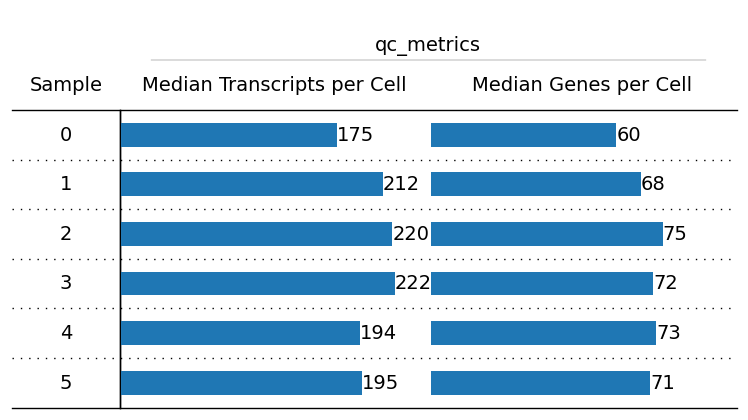

In [18]:
plot_overview(exp)

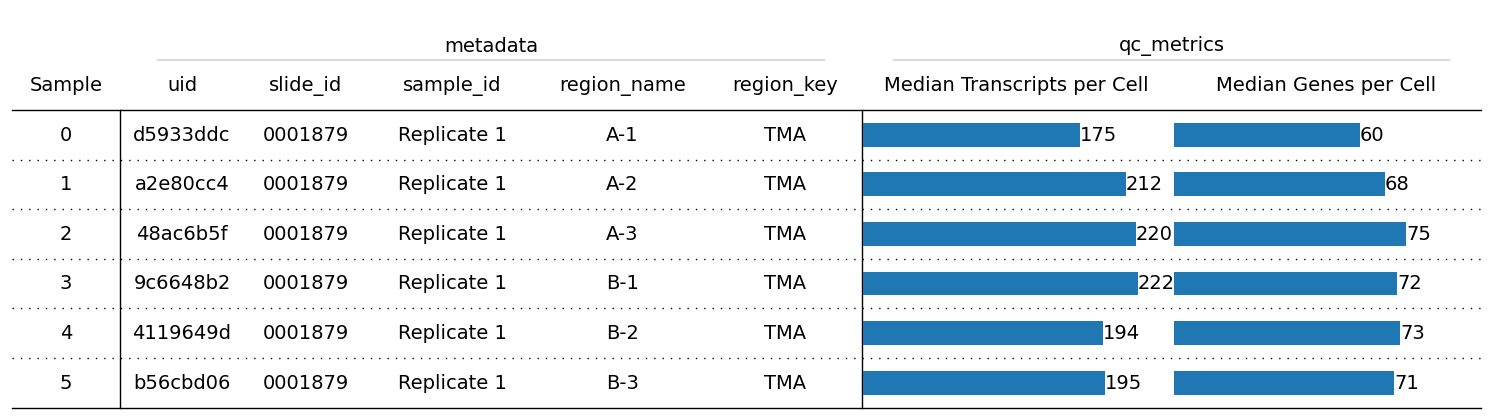

In [19]:
plot_overview(exp, cells_layer="main", columns_to_plot=["uid", "slide_id", "sample_id", "region_name", "region_key"], index=True)

## Iterate through `InSituExperiment`

The `.iterdata()` method returns a generator object, allowing you to iterate through the metadata and data of each dataset in the `InSituExperiment`. The individual datasets are returned as `InSituData` objects.

In [20]:
for metadata, data in exp.iterdata():
    print(f"Metadata:\n{metadata[:3]}\nData:\n{data}")

Metadata:
uid             d5933ddc
slide_id         0001879
sample_id    Replicate 1
Name: 0, dtype: object
Data:
InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		None

    ➤ images
       CD20:	(4706, 4706)
       HE:	(4706, 4706, 3)
       HER2:	(4706, 4706)
       nuclei:	(4706, 4706)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 4847 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_lo

## Add new metadata

In the following section different scenarios for adding new metadata are shown.

In [21]:
exp1 = InSituExperiment.from_regions(
    data=xd, region_key="demo_regions"
)

Region1
Region2
Region3


In [22]:
exp1

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1
1     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2
2     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3

In [23]:
exp2 = exp1.copy()
exp2.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata.csv",
    by="region_name", overwrite=True
)

In [24]:
exp2

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_name therapy   organ      test region_key
0     0d1f50a5  ++-++  0001879  Replicate 1     Region1   drugC   liver  negative       key1
1     16fe63e1  ++-++  0001879  Replicate 1     Region2   drugD    lung      test       key3
2     7900691c  ++-++  0001879  Replicate 1     Region3   drugE  spleen  positive       key2

In [25]:
exp3 = exp1.copy()
exp3.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata.csv",
    by="region_name", overwrite=False
)

In [26]:
exp3

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name   organ      test therapy
0     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1   liver  negative   drugC
1     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2    lung      test   drugD
2     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3  spleen  positive   drugE

In [27]:
exp4 = exp1.copy()
exp4.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata2.csv",
    by="region_name", overwrite=False
)

In [28]:
exp4

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name   organ      test therapy
0     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1   liver  negative   drugC
1     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2     NaN       NaN     NaN
2     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3  spleen  positive   drugE

In [29]:
exp5 = exp1.copy()
exp5.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata2.csv",
    by="region_name", overwrite=True
)

In [30]:
exp5

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_name therapy   organ      test region_key
0     0d1f50a5  ++-++  0001879  Replicate 1     Region1   drugC   liver  negative       key1
1     16fe63e1  ++-++  0001879  Replicate 1     Region2     NaN     NaN       NaN        NaN
2     7900691c  ++-++  0001879  Replicate 1     Region3   drugE  spleen  positive       key2

Concatenate multiple `InSituExperiment` objects

In [32]:
exp

InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     d5933ddc  ++-++  0001879  Replicate 1        TMA         A-1
1     a2e80cc4  ++--+  0001879  Replicate 1        TMA         A-2
2     48ac6b5f  ++--+  0001879  Replicate 1        TMA         A-3
3     9c6648b2  ++-++  0001879  Replicate 1        TMA         B-1
4     4119649d  ++-++  0001879  Replicate 1        TMA         B-2
5     b56cbd06  ++-++  0001879  Replicate 1        TMA         B-3

In [33]:
exp1

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1
1     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2
2     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3

In [34]:
exp_concat = InSituExperiment.concat(
    objs={
        "exp_TMA": exp,
        "exp_demo_regions": exp1
    },
    new_col_name="name"
    )

C:\Users\ge37voy\Github\InSituPy\insitupy\experiment\data.py:240: UserWarning: Observation names are not unique across all datasets.
  warnings.warn("Observation names are not unique across all datasets.")


In [35]:
exp_concat

InSituExperiment with 9 samples:
           uid  CITAR slide_id    sample_id    region_key region_name            name
0     d5933ddc  ++-++  0001879  Replicate 1           TMA         A-1         exp_TMA
1     a2e80cc4  ++--+  0001879  Replicate 1           TMA         A-2         exp_TMA
2     48ac6b5f  ++--+  0001879  Replicate 1           TMA         A-3         exp_TMA
3     9c6648b2  ++-++  0001879  Replicate 1           TMA         B-1         exp_TMA
4     4119649d  ++-++  0001879  Replicate 1           TMA         B-2         exp_TMA
5     b56cbd06  ++-++  0001879  Replicate 1           TMA         B-3         exp_TMA
6     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1  exp_demo_re...
7     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2  exp_demo_re...
8     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3  exp_demo_re...

In [36]:
exp_concat = InSituExperiment.concat(
    objs=[exp, exp1])

C:\Users\ge37voy\Github\InSituPy\insitupy\experiment\data.py:240: UserWarning: Observation names are not unique across all datasets.
  warnings.warn("Observation names are not unique across all datasets.")


In [37]:
exp_concat

InSituExperiment with 9 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     d5933ddc  ++-++  0001879  Replicate 1           TMA         A-1
1     a2e80cc4  ++--+  0001879  Replicate 1           TMA         A-2
2     48ac6b5f  ++--+  0001879  Replicate 1           TMA         A-3
3     9c6648b2  ++-++  0001879  Replicate 1           TMA         B-1
4     4119649d  ++-++  0001879  Replicate 1           TMA         B-2
5     b56cbd06  ++-++  0001879  Replicate 1           TMA         B-3
6     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1
7     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2
8     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3

## Indexing and selection of data within `InSituExperiment`

The `InSituExperiment` class allows simple selection and filtering of data using indices or True/False masks.

### Example 1: Select datasets by index

In [38]:
exp_indexed = exp_concat[:3]

In [39]:
exp_indexed

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     d5933ddc  ++-++  0001879  Replicate 1        TMA         A-1
1     a2e80cc4  ++--+  0001879  Replicate 1        TMA         A-2
2     48ac6b5f  ++--+  0001879  Replicate 1        TMA         A-3

In [40]:
exp_indexed.show(2)

Also a list of indices can be used for this.

In [41]:
exp_concat[[0,1,4]]

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     d5933ddc  ++-++  0001879  Replicate 1        TMA         A-1
1     a2e80cc4  ++--+  0001879  Replicate 1        TMA         A-2
2     4119649d  ++-++  0001879  Replicate 1        TMA         B-2

### Example 2: Select only datasets with a "1" in the region name using a mask

In [42]:
filtering_mask = exp_concat.metadata["region_name"].str.contains("1", na=False) # NaN values are filled with False
exp_filtered = exp_concat[filtering_mask]

### Example 3: Query data

The `.query()` function can be used to the [`pandas.DataFrame.query`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html) function.

In [43]:
exp_concat.query(
    criteria="region_key == 'demo_regions'"
)

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1
1     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2
2     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3

## Save `InSituExperiment`

In [44]:
exp_concat.saveas(CACHE / "out/test_insituexperiment", overwrite=True)

100%|██████████| 9/9 [00:49<00:00,  5.55s/it]


## Reload `InSituExperiment`

In [45]:
exp_reloaded = InSituExperiment.read(CACHE / "out/test_insituexperiment/")

100%|██████████| 9/9 [00:00<00:00, 857.07it/s]


In [46]:
exp_reloaded.load_all()

100%|██████████| 9/9 [00:04<00:00,  1.92it/s]


In [47]:
exp_reloaded

InSituExperiment with 9 samples:
           uid  CITAR  slide_id    sample_id    region_key region_name
0     d5933ddc  ++-++      1879  Replicate 1           TMA         A-1
1     a2e80cc4  ++--+      1879  Replicate 1           TMA         A-2
2     48ac6b5f  ++--+      1879  Replicate 1           TMA         A-3
3     9c6648b2  ++-++      1879  Replicate 1           TMA         B-1
4     4119649d  ++-++      1879  Replicate 1           TMA         B-2
5     b56cbd06  ++-++      1879  Replicate 1           TMA         B-3
6     0d1f50a5  ++-++      1879  Replicate 1  demo_regions     Region1
7     16fe63e1  ++-++      1879  Replicate 1  demo_regions     Region2
8     7900691c  ++-++      1879  Replicate 1  demo_regions     Region3

In [48]:
exp_reloaded.show(2)

In [49]:
exp_reloaded.save()

100%|██████████| 9/9 [00:13<00:00,  1.53s/it]


In [50]:
exp_reloaded = InSituExperiment.read(CACHE / "out/test_insituexperiment/")

100%|██████████| 9/9 [00:00<00:00, 911.25it/s]


In [51]:
exp_reloaded.load_all()

100%|██████████| 9/9 [00:04<00:00,  2.12it/s]


In [52]:
exp_reloaded.data[2]

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\test_insituexperiment\data-002

    ➤ images
       CD20:	(4706, 4705)
       HE:	(4706, 4705, 3)
       HER2:	(4706, 4705)
       nuclei:	(4706, 4705)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 1807 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_colors', 'log1p', 'neigh

In [53]:
exp_reloaded.show(2)

INFO: Added 3 new annotations to key 'TestKey'


Annotations or regions can now be added to the individual datasets and by pressing the "Sync Geometries" button they are saved in the corresponding `InSituData` object:

In [56]:
exp_reloaded.data[2]

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\test_insituexperiment\data-002

    ➤ images
       CD20:	(4706, 4705)
       HE:	(4706, 4705, 3)
       HER2:	(4706, 4705)
       nuclei:	(4706, 4705)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 1807 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_colors', 'log1p', 'neigh